# 🌍 월드 모델 (World Models) 튜토리얼

> 이 노트북은 강화학습 월드 모델의 **핵심 구성요소를 직접 구현하고 실험**하는 실습 가이드다.

| 실습 | 내용 | 핵심 구현 |
|:---:|:---|:---|
| **Lab 0** | 환경 설정 | 라이브러리 설치, 시드 고정 |
| **Lab 1** | Dyna-Q 실험 | Planning 스텝 수에 따른 학습 속도 비교 |
| **Lab 2** | VAE 구현 및 학습 | Convolutional VAE, 잠재 공간 시각화 |
| **Lab 3** | MDN-RNN 시퀀스 예측 | 가우시안 혼합 분포, 궤적 롤아웃 |
| **Lab 4** | RSSM 구현 | DreamerV3 스타일 결정적/확률적 상태 분리 |
| **Lab 5** | 통합 월드 모델 + "꿈" | VAE + MDN-RNN + Controller 조합 |
| **Lab 6** | CartPole 전이 모델 | 실제 환경 데이터로 학습, Compounding Error 관찰 |

---


## 0. 환경 설정


In [ ]:
%pip install torch torchvision gymnasium numpy matplotlib tqdm -q

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal, Categorical
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"디바이스: {device}  |  PyTorch: {torch.__version__}")

디바이스: cpu  |  PyTorch: 2.9.1


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 1. 운영체제별 폰트 설정
if platform.system() == 'Windows':
    # 윈도우 맑은 고딕
    font_family = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    # 맥 애플고딕
    font_family = 'AppleGothic'
else:
    # 리눅스/코랩 나눔고딕
    font_family = 'NanumGothic'

# 2. 폰트 설정
plt.rc('font', family=font_family)
# 3. 마이너스 부호 깨짐 해결
plt.rcParams['axes.unicode_minus'] = False

---
## 01. Dyna-Q 실험: Planning 스텝의 효과

Sutton(1990)의 Dyna-Q를 구현하고, **Planning 스텝 수**에 따라 학습 속도가 어떻게 달라지는지 관찰한다.
이론적 배경은 `world_models_theory.md`의 **4.1 Dyna** 절을 참고한다.


In [12]:
class DynaQ:
    """Dyna-Q: 실제 경험 + 모델 기반 시뮬레이션으로 Q-테이블을 학습한다."""
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95,
                 epsilon=0.1, n_planning=10):
        self.Q = np.zeros((n_states, n_actions))
        self.model = {}          # (s, a) -> (s', r, done)
        self.visited_sa = []     # 경험한 상태-행동 쌍
        self.alpha, self.gamma = alpha, gamma
        self.epsilon, self.n_planning = epsilon, n_planning
        self.n_actions = n_actions

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, s, a, r, s_next, done):
        # ① Direct RL: 실제 전이로 Q-값 업데이트
        target = r if done else r + self.gamma * np.max(self.Q[s_next])
        self.Q[s, a] += self.alpha * (target - self.Q[s, a])

        # ② Model Learning: 환경 모델에 전이 저장
        self.model[(s, a)] = (s_next, r, done)
        if (s, a) not in self.visited_sa:
            self.visited_sa.append((s, a))

        # ③ Planning: 모델로 가상 경험 생성 → Q-값 추가 업데이트
        for _ in range(self.n_planning):
            if not self.visited_sa:
                break
            idx = np.random.randint(len(self.visited_sa))
            s_sim, a_sim = self.visited_sa[idx]
            s_n, r_s, d_s = self.model[(s_sim, a_sim)]
            tgt = r_s if d_s else r_s + self.gamma * np.max(self.Q[s_n])
            self.Q[s_sim, a_sim] += self.alpha * (tgt - self.Q[s_sim, a_sim])

In [13]:
class CliffWalkGrid:
    """4x12 그리드 클리프 워킹 환경"""
    def __init__(self):
        self.rows, self.cols = 4, 12
        self.start, self.goal = (3, 0), (3, 11)
        self.cliff = [(3, c) for c in range(1, 11)]

    def reset(self):
        self.pos = self.start
        return self.pos[0] * self.cols + self.pos[1]

    def step(self, action):
        r, c = self.pos
        if action == 0: r = max(r-1, 0)
        elif action == 1: r = min(r+1, self.rows-1)
        elif action == 2: c = max(c-1, 0)
        elif action == 3: c = min(c+1, self.cols-1)
        self.pos = (r, c)
        idx = r * self.cols + c
        if self.pos in self.cliff:
            return self.reset(), -100, True
        if self.pos == self.goal:
            return idx, 0, True
        return idx, -1, False

In [14]:
# 실험 실행
planning_list = [0, 5, 20, 50]
results = {}
env = CliffWalkGrid()

for n_plan in planning_list:
    agent = DynaQ(48, 4, n_planning=n_plan)
    rewards = []
    for ep in range(120):
        s = env.reset(); total = 0
        for _ in range(500):
            a = agent.select_action(s)
            s_next, r, done = env.step(a)
            agent.update(s, a, r, s_next, done)
            total += r; s = s_next
            if done: break
        rewards.append(total)
    results[n_plan] = rewards

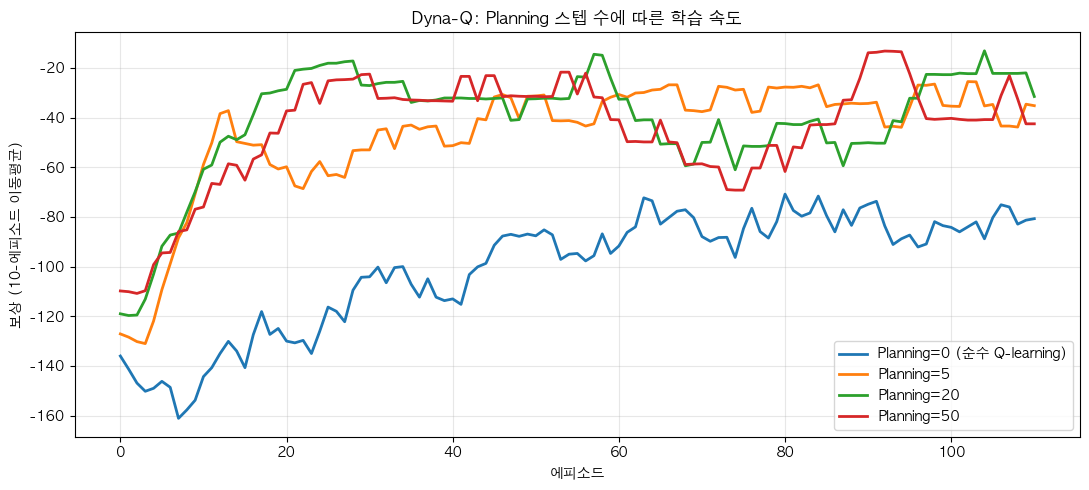

=> Planning 스텝이 많을수록 동일한 실제 경험에서 더 빠르게 학습한다!


In [15]:
# 시각화
plt.figure(figsize=(11, 5))
window = 10
for n_plan, rews in results.items():
    sm = np.convolve(rews, np.ones(window)/window, mode='valid')
    lbl = f'Planning={n_plan}' + (' (순수 Q-learning)' if n_plan == 0 else '')
    plt.plot(sm, label=lbl, linewidth=2)
plt.xlabel('에피소드'); plt.ylabel(f'보상 ({window}-에피소드 이동평균)')
plt.title('Dyna-Q: Planning 스텝 수에 따른 학습 속도', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("=> Planning 스텝이 많을수록 동일한 실제 경험에서 더 빠르게 학습한다!")

---
## 02. VAE 구현 및 학습

Convolutional VAE를 구현하고 합성 데이터로 학습한다. 재구성 품질과 잠재 공간 구조를 시각화한다.
이론은 `world_models_theory.md`의 **5장 VAE** 절을 참고한다.


In [16]:
class VAE(nn.Module):
    """Convolutional VAE — 월드 모델의 Vision 모듈이다."""
    def __init__(self, in_ch=3, z_dim=32, img_size=64):
        super().__init__()
        self.z_dim, self.img_size = z_dim, img_size

        # 인코더: (B, C, H, W) -> (mu, logvar)
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, 32,  4, 2, 1), nn.ReLU(),   # H/2
            nn.Conv2d(32,    64,  4, 2, 1), nn.ReLU(),   # H/4
            nn.Conv2d(64,    128, 4, 2, 1), nn.ReLU(),   # H/8
            nn.Conv2d(128,   256, 4, 2, 1), nn.ReLU(),   # H/16
            nn.Flatten())
        feat = 256 * (img_size // 16) ** 2
        self.fc_mu     = nn.Linear(feat, z_dim)
        self.fc_logvar = nn.Linear(feat, z_dim)

        # 디코더: z -> (B, C, H, W)
        self.fc_dec = nn.Linear(z_dim, feat)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, img_size//16, img_size//16)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32,  in_ch, 4, 2, 1), nn.Sigmoid())

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)

    def decode(self, z):
        return self.decoder(self.fc_dec(z))

    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparameterize(mu, lv)
        return self.decode(z), mu, lv, z

    @staticmethod
    def loss_fn(x, xr, mu, lv, beta=1.0):
        recon = F.binary_cross_entropy(xr, x, reduction='sum') / x.size(0)
        kl = -0.5 * torch.sum(1 + lv - mu**2 - lv.exp()) / x.size(0)
        return recon + beta*kl, recon, kl

In [17]:
vae = VAE(3, 8, 64).to(device)
print(f"VAE 파라미터: {sum(p.numel() for p in vae.parameters()):,}")

VAE 파라미터: 1,482,451


합성 이미지 생성 중...


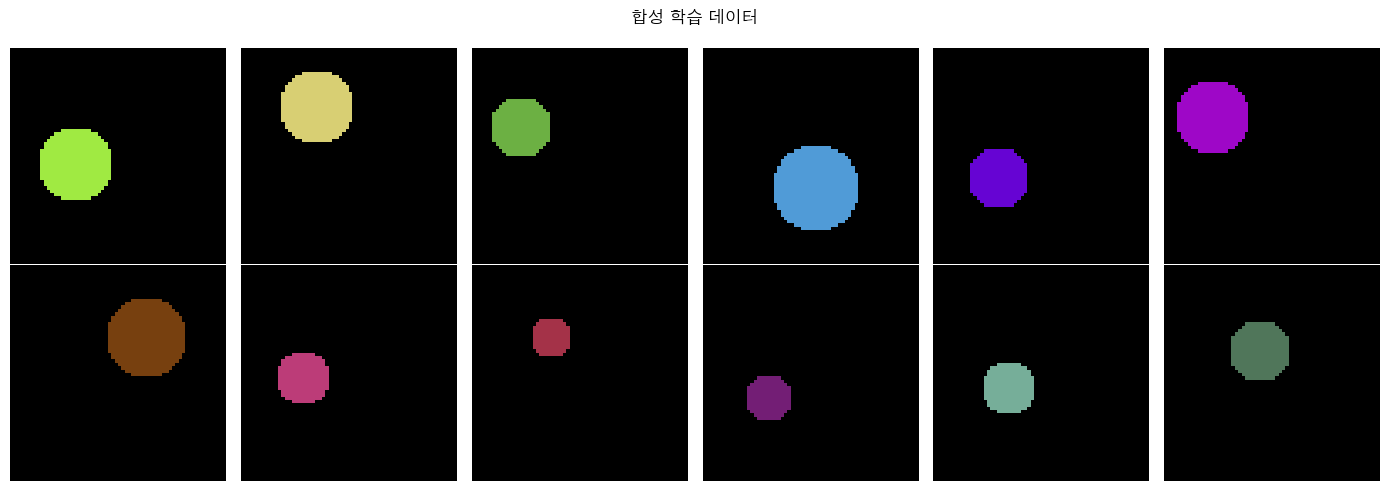

In [18]:
# 합성 데이터 생성: 다양한 색/위치/크기의 원
def make_data(n=2000, sz=64):
    imgs = np.zeros((n, 3, sz, sz), dtype=np.float32)
    labs = np.zeros((n, 6), dtype=np.float32)
    yy, xx = np.mgrid[0:sz, 0:sz]
    for i in range(n):
        cx, cy = np.random.randint(14, sz-14, 2)
        r = np.random.randint(5, 14)
        c = np.random.rand(3)
        mask = ((yy-cy)**2 + (xx-cx)**2) < r**2
        for ch in range(3):
            imgs[i, ch] = mask * c[ch]
        labs[i] = [cx/sz, cy/sz, r/14, *c]
    return imgs, labs

print("합성 이미지 생성 중...")
X_np, Y_np = make_data(2000, 64)
X_train = torch.tensor(X_np, device=device)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(12):
    axes[i//6, i%6].imshow(X_np[i].transpose(1,2,0)); axes[i//6, i%6].axis('off')

plt.suptitle('합성 학습 데이터', fontweight='bold'); plt.tight_layout(); plt.show()

In [20]:
# VAE 학습
def train_vae(model, data, epochs=50, bs=64, lr=1e-3, beta=0.5):
    opt = optim.Adam(model.parameters(), lr=lr)
    n = data.size(0)
    hist = {'total': [], 'recon': [], 'kl': []}
    for ep in range(1, epochs+1):
        model.train(); idx = torch.randperm(n, device=data.device)
        tot, rec, kld, nb = 0, 0, 0, 0
        for s in range(0, n, bs):
            b = data[idx[s:s+bs]]
            xr, mu, lv, _ = model(b)
            loss, rl, kl = model.loss_fn(b, xr, mu, lv, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item(); rec += rl.item(); kld += kl.item(); nb += 1
        hist['total'].append(tot/nb); hist['recon'].append(rec/nb); hist['kl'].append(kld/nb)
        if ep % 10 == 0:
            print(f"  Epoch {ep:3d}  Total={tot/nb:.1f}  Recon={rec/nb:.1f}  KL={kld/nb:.2f}")
    return hist

In [22]:
# VAE 학습
print("VAE 학습 시작 (beta=0.5)...")
hist = train_vae(vae, X_train, 50, beta=0.5)

VAE 학습 시작 (beta=0.5)...
  Epoch  10  Total=607.0  Recon=591.6  KL=30.74
  Epoch  20  Total=564.4  Recon=549.9  KL=29.01
  Epoch  30  Total=549.9  Recon=535.2  KL=29.44
  Epoch  40  Total=537.7  Recon=523.2  KL=28.90
  Epoch  50  Total=532.2  Recon=518.1  KL=28.20


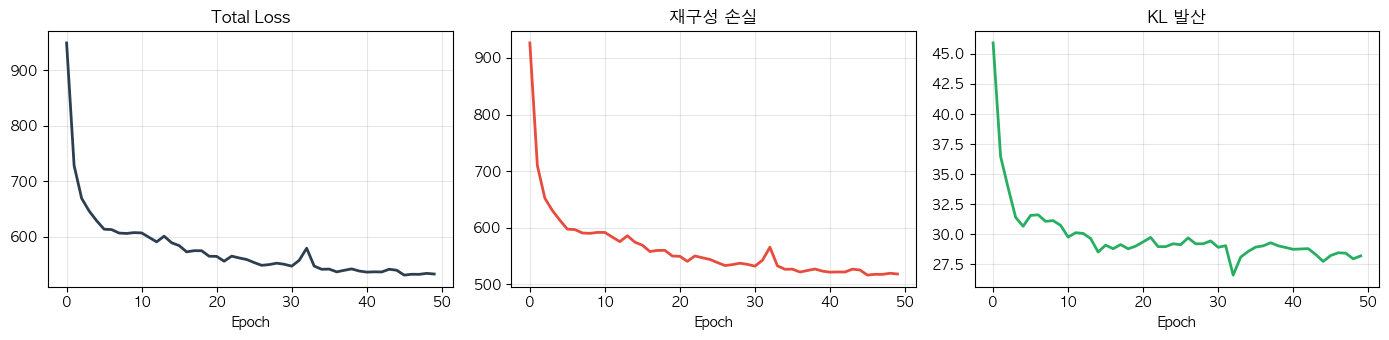

In [32]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, k, c, t in zip(axes, ['total','recon','kl'],
    ['#2C3E50','#E74C3C','#27AE60'], ['Total Loss','재구성 손실','KL 발산']):
    ax.plot(hist[k], color=c, lw=2); ax.set_xlabel('Epoch')
    ax.set_title(t, fontweight='bold'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

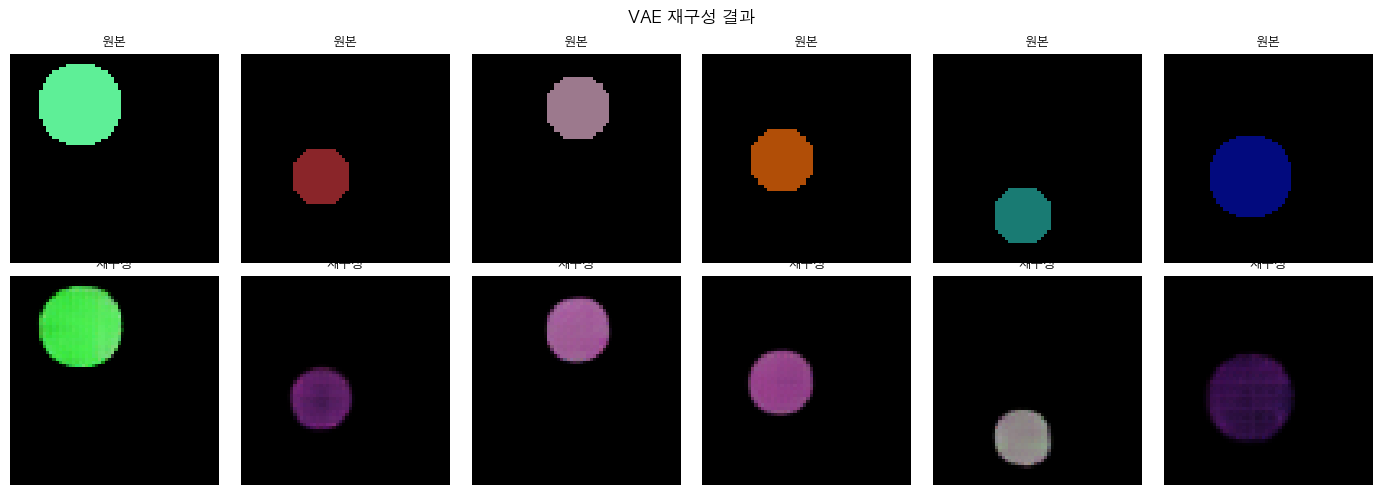

In [23]:
# 재구성 결과 + 잠재 공간 시각화
vae.eval()
with torch.no_grad():
    idx = np.random.choice(len(X_train), 6, replace=False)
    samp = X_train[idx]; rec, _, _, _ = vae(samp)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0,i].imshow(samp[i].cpu().numpy().transpose(1,2,0))
    axes[0,i].set_title('원본', fontsize=9); axes[0,i].axis('off')
    axes[1,i].imshow(rec[i].cpu().numpy().transpose(1,2,0))
    axes[1,i].set_title('재구성', fontsize=9); axes[1,i].axis('off')
plt.suptitle('VAE 재구성 결과', fontweight='bold'); plt.tight_layout(); plt.show()

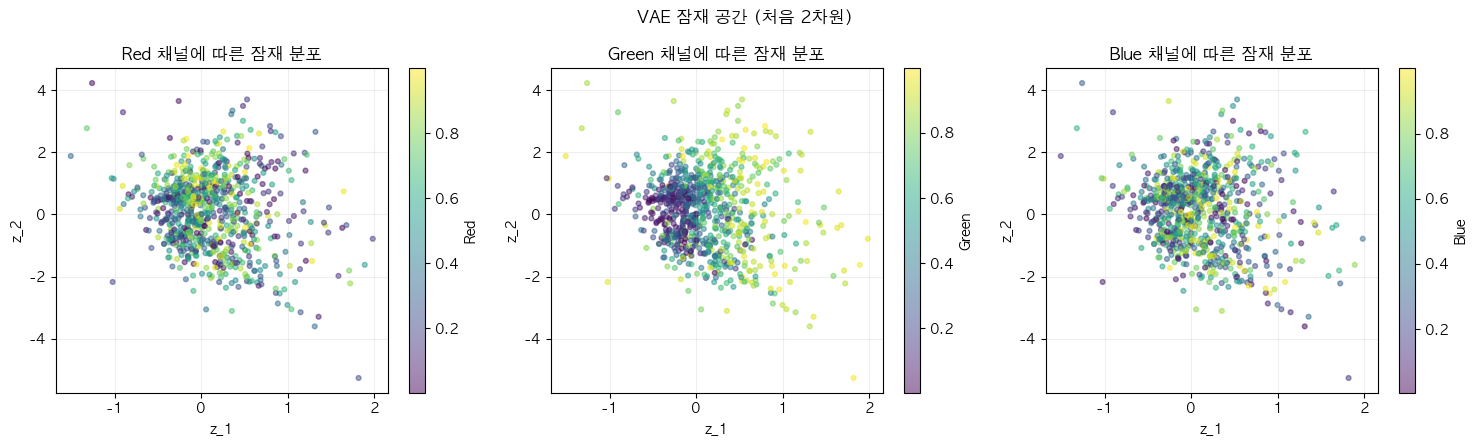

In [24]:
# 잠재 공간 2D 투영
with torch.no_grad():
    _, mu_all, _, _ = vae(X_train[:800])
    z_np = mu_all.cpu().numpy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, ci, cn in zip(axes, [3,4,5], ['Red','Green','Blue']):
    sc = ax.scatter(z_np[:,0], z_np[:,1], c=Y_np[:800,ci], cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=ax, label=cn)
    ax.set_xlabel('z_1'); ax.set_ylabel('z_2')
    ax.set_title(f'{cn} 채널에 따른 잠재 분포'); ax.grid(alpha=0.2)
plt.suptitle('VAE 잠재 공간 (처음 2차원)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 03. MDN-RNN 시퀀스 예측

가우시안 혼합 분포로 다음 상태를 예측하는 MDN-RNN을 구현하고, 2D 물리 시뮬레이션 궤적을 롤아웃한다.
이론은 `world_models_theory.md`의 **6장 MDN-RNN** 절을 참고한다.


In [42]:
class MDNRNN(nn.Module):
    """Mixture Density Network + LSTM — 월드 모델의 Memory 모듈이다."""
    def __init__(self, z_dim=4, a_dim=2, h_dim=128, n_mix=5):
        super().__init__()
        self.z_dim, self.h_dim, self.n_mix = z_dim, h_dim, n_mix
        self.lstm = nn.LSTM(z_dim + a_dim, h_dim, batch_first=True)
        self.fc_pi    = nn.Linear(h_dim, n_mix)
        self.fc_mu    = nn.Linear(h_dim, n_mix * z_dim)
        self.fc_sigma = nn.Linear(h_dim, n_mix * z_dim)

    def forward(self, z, a, hidden=None):
        out, hidden = self.lstm(torch.cat([z, a], -1), hidden)
        B, T, _ = out.shape
        pi = F.softmax(self.fc_pi(out), dim=-1)
        mu = self.fc_mu(out).view(B, T, self.n_mix, self.z_dim)
        sigma = F.softplus(self.fc_sigma(out)).view(B, T, self.n_mix, self.z_dim) + 1e-4
        return pi, mu, sigma, hidden

    def mdn_loss(self, pi, mu, sigma, target):
        target = target.unsqueeze(2).expand_as(mu)
        lp = Normal(mu, sigma).log_prob(target).sum(-1)
        return -torch.logsumexp(torch.log(pi + 1e-8) + lp, dim=-1).mean()

    def sample(self, pi, mu, sigma, tau=1.0):
        pi_adj = pi ** (1.0/tau)
        pi_adj = pi_adj / pi_adj.sum(-1, keepdim=True)
        k = Categorical(pi_adj).sample()
        B, T = k.shape
        ke = k.unsqueeze(-1).unsqueeze(-1).expand(B, T, 1, self.z_dim)
        m = mu.gather(2, ke).squeeze(2)
        s = sigma.gather(2, ke).squeeze(2) * tau
        return m + s * torch.randn_like(s)

print("MDNRNN 클래스 정의 완료")

MDNRNN 클래스 정의 완료


In [43]:
# 2D 물리 시뮬레이션 데이터 생성
def make_physics(n=1000, T=30, d=4):
    seqs = np.zeros((n, T, d), dtype=np.float32)
    acts = np.zeros((n, T, 2), dtype=np.float32)
    for i in range(n):
        s = np.random.randn(d) * 0.3; seqs[i, 0] = s
        for t in range(T-1):
            a = np.random.randn(2) * 0.1; acts[i, t] = a
            s = s.copy(); s[2:] += a; s[:2] += s[2:]
            s += np.random.randn(d) * 0.02; seqs[i, t+1] = s
    return seqs, acts

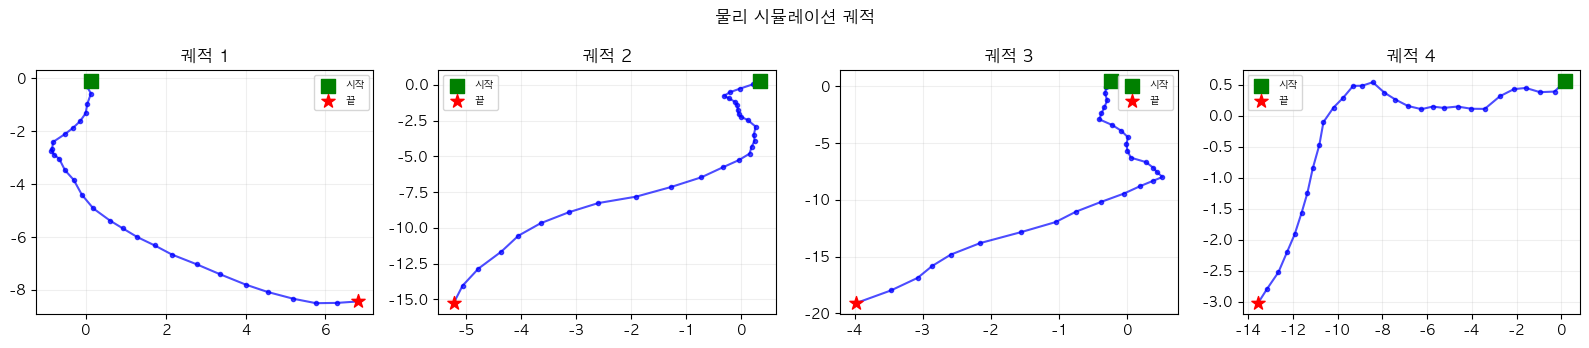

In [44]:
S_np, A_np = make_physics(1000, 30, 4)
S_t = torch.tensor(S_np, device=device)
A_t = torch.tensor(A_np, device=device)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, ax in enumerate(axes):
    tr = S_np[i]
    ax.plot(tr[:,0], tr[:,1], 'b-o', ms=3, alpha=0.7)
    ax.scatter(*tr[0,:2], c='green', s=100, marker='s', zorder=5, label='시작')
    ax.scatter(*tr[-1,:2], c='red', s=100, marker='*', zorder=5, label='끝')
    ax.set_title(f'궤적 {i+1}'); ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.suptitle('물리 시뮬레이션 궤적', fontweight='bold'); plt.tight_layout(); plt.show()

In [45]:
# MDN-RNN 학습
mdn_rnn = MDNRNN(4, 2, 128, 5).to(device)
opt = optim.Adam(mdn_rnn.parameters(), lr=1e-3)
losses = []
EP, BS = 80, 128

print("MDN-RNN 학습...")
for ep in range(1, EP+1):
    mdn_rnn.train()
    idx = torch.randperm(S_t.size(0), device=device)
    el, nb = 0, 0
    for s in range(0, S_t.size(0), BS):
        bi = idx[s:s+BS]
        pi, mu, sig, _ = mdn_rnn(S_t[bi,:-1], A_t[bi,:-1])
        loss = mdn_rnn.mdn_loss(pi, mu, sig, S_t[bi,1:])
        opt.zero_grad(); loss.backward(); opt.step()
        el += loss.item(); nb += 1
    losses.append(el/nb)
    if ep % 20 == 0: print(f"  Epoch {ep:3d}  Loss={losses[-1]:.4f}")

MDN-RNN 학습...
  Epoch  20  Loss=2.8254
  Epoch  40  Loss=-3.9393
  Epoch  60  Loss=-5.3614
  Epoch  80  Loss=-6.5188


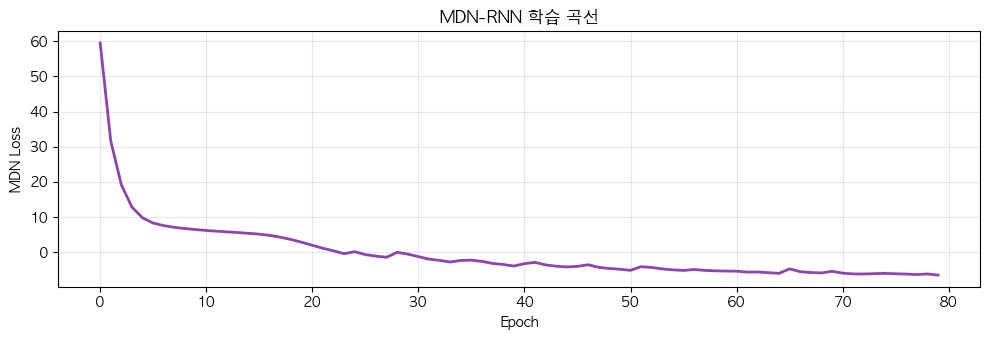

In [46]:
plt.figure(figsize=(10, 3.5))
plt.plot(losses, lw=2, color='#8E44AD')
plt.xlabel('Epoch'); plt.ylabel('MDN Loss')
plt.title('MDN-RNN 학습 곡선', fontweight='bold'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [47]:
# 자기회귀 롤아웃 + 시각화
mdn_rnn.eval()
def rollout(mdl, z0, acts, steps):
    preds = [z0.squeeze().cpu().numpy()]; z, h = z0, None  # ✅ 수정된 부분
    with torch.no_grad():
        for t in range(steps):
            pi, mu, sig, h = mdl(z, acts[:, t:t+1], h)
            z = mdl.sample(pi, mu, sig, tau=0.5)
            preds.append(z.squeeze().cpu().numpy())
    return np.array(preds)

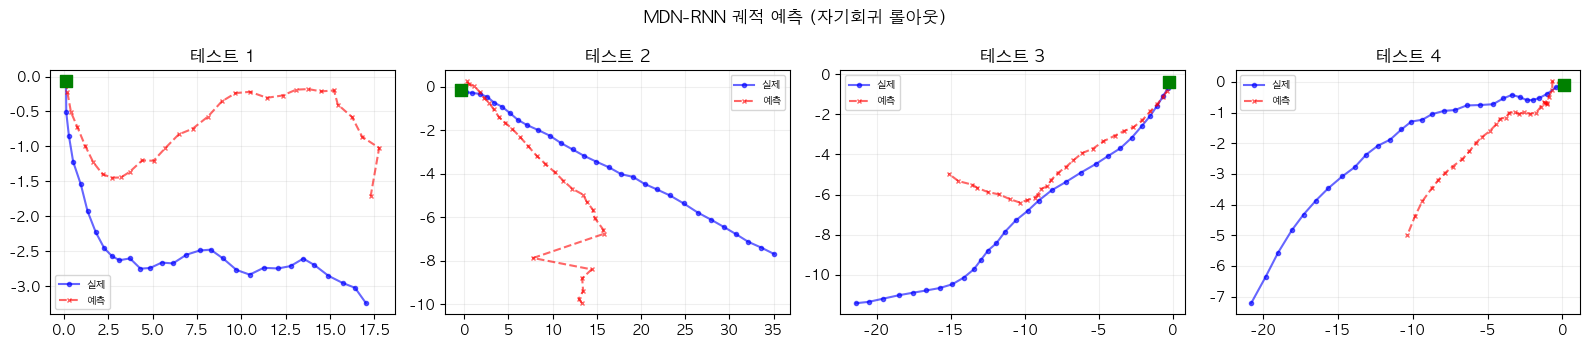

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, ax in enumerate(axes):
    ti = np.random.randint(len(S_t))
    actual = S_t[ti].cpu().numpy()
    pred = rollout(mdn_rnn, S_t[ti:ti+1,:1], A_t[ti:ti+1], len(actual)-1)
    ax.plot(actual[:,0], actual[:,1], 'b-o', ms=3, alpha=0.6, label='실제')
    ax.plot(pred[:,0], pred[:,1], 'r--x', ms=3, alpha=0.6, label='예측')
    ax.scatter(*actual[0,:2], c='green', s=80, marker='s', zorder=5)
    ax.set_title(f'테스트 {i+1}'); ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.suptitle('MDN-RNN 궤적 예측 (자기회귀 롤아웃)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 04. RSSM 구현 — DreamerV3 스타일

결정적 상태(GRU)와 확률적 상태(카테고리컬)를 분리하는 RSSM을 구현한다.
이론은 `world_models_theory.md`의 **7장 RSSM** 절을 참고한다.


In [33]:
class SimpleRSSM(nn.Module):
    """DreamerV3 스타일 RSSM: 결정적(GRU) + 확률적(카테고리컬) 상태 분리"""
    def __init__(self, obs_dim=32, act_dim=4, h_dim=200,
                 stoch_dim=30, stoch_classes=32):
        super().__init__()
        self.h_dim, self.sd, self.sc = h_dim, stoch_dim, stoch_classes
        self.st = stoch_dim * stoch_classes

        self.gru = nn.GRUCell(self.st + act_dim, h_dim)
        self.prior_net = nn.Sequential(
            nn.Linear(h_dim, 200), nn.ELU(), nn.Linear(200, self.st))
        self.post_net = nn.Sequential(
            nn.Linear(h_dim + obs_dim, 200), nn.ELU(), nn.Linear(200, self.st))

    def initial(self, bs, dev):
        return (torch.zeros(bs, self.h_dim, device=dev),
                torch.zeros(bs, self.st, device=dev))

    def _dist(self, logits):
        return F.softmax(logits.view(-1, self.sd, self.sc), dim=-1)

    def prior(self, h):     return self._dist(self.prior_net(h))
    def posterior(self, h, obs): return self._dist(self.post_net(torch.cat([h, obs], -1)))

    def step(self, s, h, a):
        return self.gru(torch.cat([s.view(-1, self.st), a], -1), h)

    def sample(self, probs):
        if self.training:
            return F.gumbel_softmax(torch.log(probs + 1e-8), hard=True, dim=-1)
        return F.one_hot(probs.argmax(-1), self.sc).float()

In [34]:
# RSSM 테스트
rssm = SimpleRSSM(32, 4).to(device)
h, s = rssm.initial(8, device)
h_new = rssm.step(s, h, torch.randn(8, 4, device=device))
prior_p = rssm.prior(h_new)
s_new = rssm.sample(prior_p)

print(f"결정적 상태 h : {h_new.shape}")
print(f"Prior 분포    : {prior_p.shape}  (30 카테고리 x 32 클래스)")
print(f"확률적 상태 s : {s_new.shape}")
print(f"파라미터 수   : {sum(p.numel() for p in rssm.parameters()):,}")

결정적 상태 h : torch.Size([8, 200])
Prior 분포    : torch.Size([8, 30, 32])  (30 카테고리 x 32 클래스)
확률적 상태 s : torch.Size([8, 30, 32])
파라미터 수   : 1,172,320


---
## 05. 통합 월드 모델 + "꿈" 시뮬레이션

VAE(Vision) + MDN-RNN(Memory) + Controller를 결합한 Ha & Schmidhuber(2018) 스타일 월드 모델을 구축하고, 실제 환경 없이 내부에서 궤적을 생성("꿈")한다.


In [35]:
class Controller(nn.Module):
    """정책 네트워크: (z, h) -> action"""
    def __init__(self, z_dim=16, h_dim=128, a_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim+h_dim, 64), nn.ReLU(),
            nn.Linear(64, a_dim), nn.Tanh())
    def forward(self, z, h):
        return self.net(torch.cat([z, h], -1))


class WorldModel(nn.Module):
    """Ha & Schmidhuber (2018) 스타일 통합 월드 모델"""
    def __init__(self, in_ch=3, z_dim=16, h_dim=128, a_dim=2, n_mix=3, img_sz=64):
        super().__init__()
        self.z_dim, self.h_dim = z_dim, h_dim
        self.vae  = VAE(in_ch, z_dim, img_sz)
        self.rnn  = MDNRNN(z_dim, a_dim, h_dim, n_mix)
        self.ctrl = Controller(z_dim, h_dim, a_dim)

    def dream(self, z0, n_steps, hidden=None):
        """'꿈' 모드: 모델 내부에서 자기회귀적으로 궤적 생성"""
        traj, acts = [z0.detach().cpu().numpy()], []; z = z0
        with torch.no_grad():
            for _ in range(n_steps):
                hv = hidden[0].squeeze(0) if hidden else torch.zeros(
                    z.size(0), self.h_dim, device=z.device)
                a = self.ctrl(z, hv); acts.append(a.cpu().numpy())
                pi, mu, sig, hidden = self.rnn(z.unsqueeze(1), a.unsqueeze(1), hidden)
                z = self.rnn.sample(pi, mu, sig, tau=0.7).squeeze(1)
                traj.append(z.cpu().numpy())
        return np.array(traj), np.array(acts)

In [36]:
wm = WorldModel(3, 16, 128, 2, 3).to(device)
print("통합 월드 모델:")
for nm, m in [('VAE',wm.vae), ('MDN-RNN',wm.rnn), ('Controller',wm.ctrl)]:
    print(f"  {nm:12s}: {sum(p.numel() for p in m.parameters()):>8,} params")

print(f"  {'Total':12s}: {sum(p.numel() for p in wm.parameters()):>8,} params")

통합 월드 모델:
  VAE         : 1,580,771 params
  MDN-RNN     :   88,547 params
  Controller  :    9,410 params
  Total       : 1,678,728 params


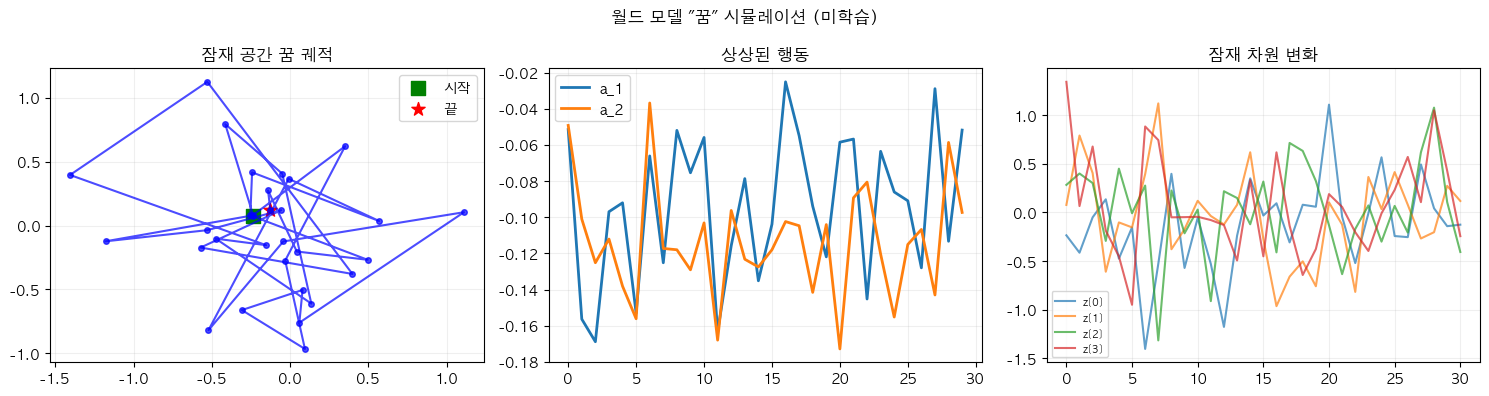

In [37]:
# "꿈" 시뮬레이션
z0 = torch.randn(1, 16, device=device)
dz, da = wm.dream(z0, 30)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(dz[:,0,0], dz[:,0,1], 'b-o', ms=4, alpha=0.7)
axes[0].scatter(*dz[0,0,:2], c='green', s=100, marker='s', label='시작')
axes[0].scatter(*dz[-1,0,:2], c='red', s=100, marker='*', label='끝')
axes[0].set_title('잠재 공간 꿈 궤적'); axes[0].legend(); axes[0].grid(alpha=0.2)

axes[1].plot(da[:,0,0], label='a_1', lw=2); axes[1].plot(da[:,0,1], label='a_2', lw=2)
axes[1].set_title('상상된 행동'); axes[1].legend(); axes[1].grid(alpha=0.2)

for d in range(4):
    axes[2].plot(dz[:,0,d], label=f'z[{d}]', alpha=0.7)
axes[2].set_title('잠재 차원 변화'); axes[2].legend(fontsize=7); axes[2].grid(alpha=0.2)

plt.suptitle('월드 모델 "꿈" 시뮬레이션 (미학습)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 06. CartPole 환경 전이 모델 — Compounding Error 관찰

Gymnasium CartPole-v1에서 실제 데이터를 수집하고, MLP 전이 모델을 학습한 뒤, 다중 스텝 롤아웃에서 **오차 누적 현상**을 직접 관찰한다.


In [38]:
import gymnasium as gym

def collect_data(n_ep=500, max_s=200):
    env = gym.make('CartPole-v1')
    ss, aa, ns, rr, dd = [], [], [], [], []
    for _ in range(n_ep):
        s, _ = env.reset()
        for _ in range(max_s):
            a = env.action_space.sample()
            sn, r, tm, tr, _ = env.step(a)
            ss.append(s); aa.append(a); ns.append(sn); rr.append(r)
            dd.append(tm or tr); s = sn
            if tm or tr: break
    env.close()
    return (np.array(ss, np.float32), np.array(aa, np.int64),
            np.array(ns, np.float32), np.array(rr, np.float32), np.array(dd))

print("CartPole 데이터 수집 중...")
cp_s, cp_a, cp_ns, cp_r, cp_d = collect_data(500)
print(f"전이 수: {len(cp_s):,}")

CartPole 데이터 수집 중...
전이 수: 11,125


전이 모델 학습...
  Epoch  15  Loss=0.00000
  Epoch  30  Loss=0.00000
  Epoch  45  Loss=0.00000
  Epoch  60  Loss=0.00000


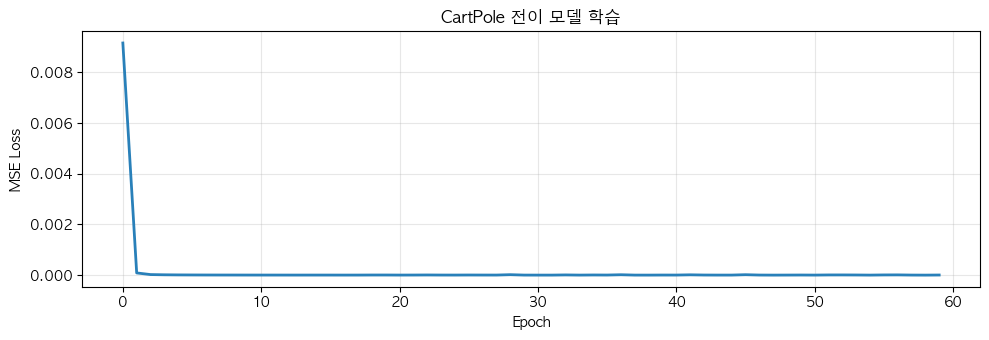

In [39]:
class DynamicsModel(nn.Module):
    """MLP 전이 모델: (state, action_onehot) -> (delta_state, reward)"""
    def __init__(self, s_dim=4, a_dim=2, hid=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim+a_dim, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, s_dim+1))
    def forward(self, s, a_oh):
        o = self.net(torch.cat([s, a_oh], -1))
        return o[:, :-1], o[:, -1]

a_oh = np.eye(2, dtype=np.float32)[cp_a]
delta = cp_ns - cp_s
ds = TensorDataset(torch.tensor(cp_s), torch.tensor(a_oh),
                   torch.tensor(delta), torch.tensor(cp_r))
dl = DataLoader(ds, 256, shuffle=True)

dyn = DynamicsModel().to(device)
opt_d = optim.Adam(dyn.parameters(), lr=3e-3)

print("전이 모델 학습...")
dl_losses = []
for ep in range(1, 61):
    el, nb = 0, 0; dyn.train()
    for sb, ab, db, rb in dl:
        sb, ab, db, rb = [t.to(device) for t in (sb, ab, db, rb)]
        dp, rp = dyn(sb, ab)
        loss = F.mse_loss(dp, db) + 0.1*F.mse_loss(rp, rb)
        opt_d.zero_grad(); loss.backward(); opt_d.step()
        el += loss.item(); nb += 1
    dl_losses.append(el/nb)
    if ep % 15 == 0: print(f"  Epoch {ep:3d}  Loss={dl_losses[-1]:.5f}")

plt.figure(figsize=(10, 3.5))
plt.plot(dl_losses, lw=2, color='#2980B9')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('CartPole 전이 모델 학습', fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


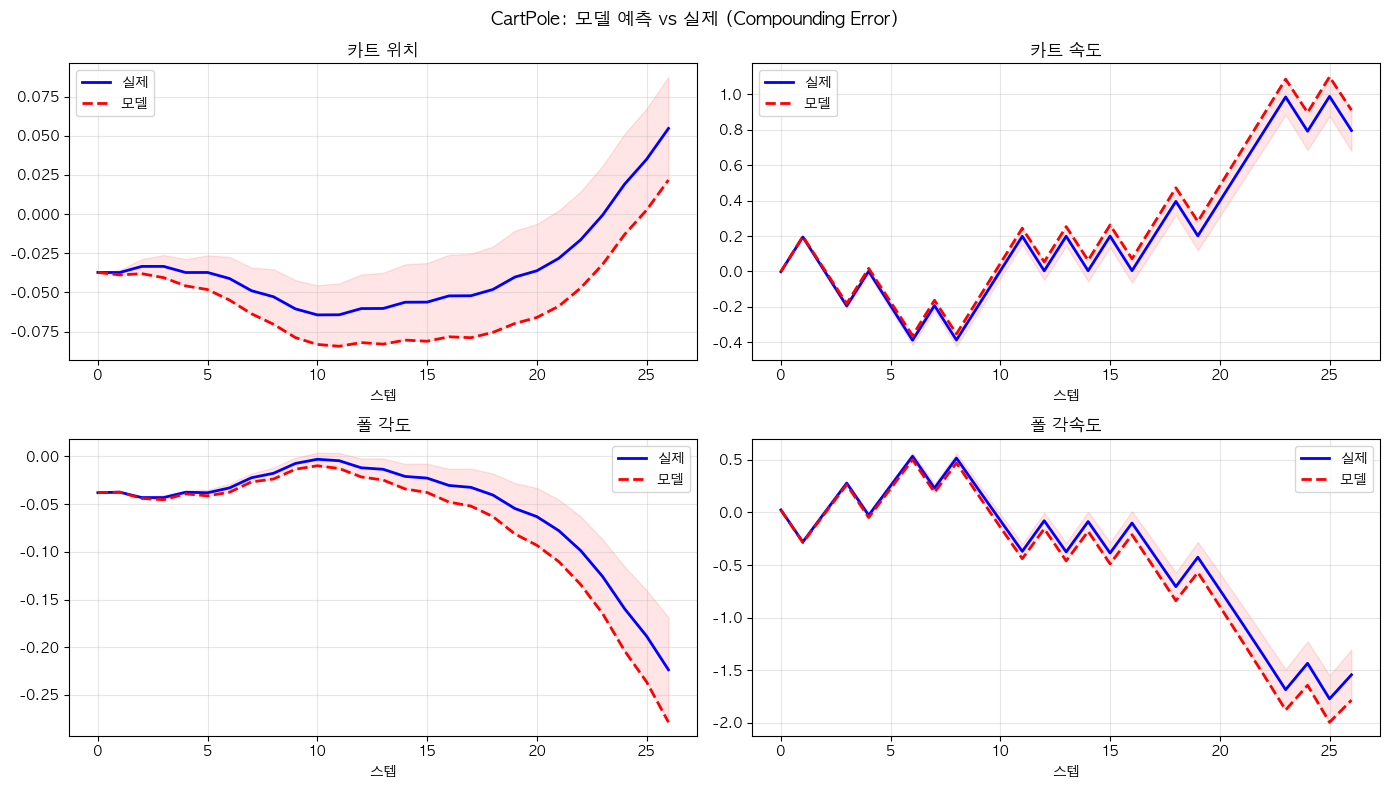

=> 초반에는 정확하지만, 스텝이 쌓일수록 오차가 누적된다!


In [40]:
# 모델 롤아웃 vs 실제 환경 비교
def compare_rollout(dyn_m, max_steps=80):
    env = gym.make('CartPole-v1')
    sr, _ = env.reset(); sm = sr.copy()
    real, model = [sr.copy()], [sm.copy()]
    for _ in range(max_steps):
        a = env.action_space.sample()
        aoh = np.eye(2, dtype=np.float32)[a]
        sn, _, tm, tr, _ = env.step(a)
        real.append(sn.copy())
        with torch.no_grad():
            st = torch.tensor(sm, dtype=torch.float32, device=device).unsqueeze(0)
            at = torch.tensor(aoh, dtype=torch.float32, device=device).unsqueeze(0)
            dp, _ = dyn_m(st, at)
            sm = sm + dp.squeeze().cpu().numpy()
        model.append(sm.copy()); sr = sn
        if tm or tr: break
    env.close()
    return np.array(real), np.array(model)

dyn.eval()
real_t, model_t = compare_rollout(dyn, 80)

names = ['카트 위치', '카트 속도', '폴 각도', '폴 각속도']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
nc = min(len(real_t), len(model_t))
for i, (ax, nm) in enumerate(zip(axes.flat, names)):
    ax.plot(real_t[:nc, i], 'b-', lw=2, label='실제')
    ax.plot(model_t[:nc, i], 'r--', lw=2, label='모델')
    ax.set_title(nm, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlabel('스텝')
    diff = np.abs(real_t[:nc, i] - model_t[:nc, i])
    ax.fill_between(range(nc), real_t[:nc,i]-diff, real_t[:nc,i]+diff,
                     alpha=0.1, color='red')
plt.suptitle('CartPole: 모델 예측 vs 실제 (Compounding Error)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()
print("=> 초반에는 정확하지만, 스텝이 쌓일수록 오차가 누적된다!")

---
## 정리

| 실습 | 구현 내용 | 핵심 관찰 |
|:---:|:---|:---|
| **Lab 1** | Dyna-Q | Planning 스텝이 많을수록 학습이 빨라진다 |
| **Lab 2** | VAE | 잠재 공간이 색상/위치 요인별로 구조화된다 |
| **Lab 3** | MDN-RNN | 가우시안 혼합으로 확률적 전이를 포착한다 |
| **Lab 4** | RSSM | 결정적/확률적 분리로 불확실성을 모델링한다 |
| **Lab 5** | 통합 모델 | "꿈" 모드로 실제 환경 없이 궤적을 생성한다 |
| **Lab 6** | CartPole | Compounding Error가 롤아웃 길이에 따라 누적된다 |